# Inverse beamforming on an in-vivo carotid scan

This tutorial applies [`zea.inverse`](../../_autosummary/zea.inverse.rst) to an
**in-vivo carotid acquisition** (149 single-element transmits, 128 elements, from the
[off-grid-ultrasound dataset](https://zenodo.org/records/14925758) of
[van de Schaft et al., arXiv:2407.02285](https://arxiv.org/abs/2407.02285)) and
reproduces the in-vivo result of the standalone
[DAS-inversion study](https://github.com/sankethvedula/das-inverse): a scatterer-prior
inversion with 30,000 scatterers, reference pre-BF corr 0.06 and post-BF corr 0.95.

That pre-BF correlation of ≈0.06 is the honest headline: a compounded image constrains
speckle *statistics*, not the specific channel-data realization, so recovering diffuse
in-vivo channel data from one image is fundamentally limited. Compare the
[CIRS phantom tutorial](inverse_beamforming_cirs_example.ipynb) (0.84 on point targets)
and the [introductory tutorial](inverse_beamforming_example.ipynb), which sits between
the two regimes with bright points over speckle.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/inversion/inverse_beamforming_carotid_example.ipynb)
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/inversion/inverse_beamforming_carotid_example.ipynb)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from keras import ops
from matplotlib.animation import FuncAnimation, PillowWriter

import zea
from zea.inverse import DASOperator, ScattererSimulator, invert_scatterers

zea.init_device()

zea: Using backend 'jax'


-------------------GPU settings-------------------
7/8 GPUs were disabled
     memory
GPU        
0       81072
Selecting 1 GPU based on available memory.
Selected GPU 0 with Free Memory: 81072.00 MiB
--------------------------------------------------


'gpu:0'

In [3]:
# Parameters (overridden for fast CI runs, see tests/test_notebooks.py)
n_iter = 70
n_scatterers = 30000
# The scan is a 411 MB download and the inversion runs for hours; CI skips it.
run_inversion = True

## Download the scan

The in-vivo carotid scan (411 MB) comes from the off-grid-ultrasound dataset on Zenodo.
It is in the (legacy) `zea` HDF5 format and loads directly with
[`zea.File`](../../_autosummary/zea.data.file.rst).

In [4]:
DATA_DIR = Path(os.environ.get("ZEA_INVERSE_DATA_DIR", "~/zea-inverse-data")).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)

SCAN_PATH = DATA_DIR / "L11-5v_carotid1.hdf5"
SCAN_URL = "https://zenodo.org/records/14925758/files/L11-5v_carotid1.hdf5?download=1"

if run_inversion and not SCAN_PATH.exists():
    print(f"downloading {SCAN_PATH.name} (411 MB) ...")
    urllib.request.urlretrieve(SCAN_URL, SCAN_PATH)
    print(f"  -> {SCAN_PATH} ({SCAN_PATH.stat().st_size / 1e6:.0f} MB)")

## Loading a scan for inversion

We load the acquisition into [`zea.Parameters`](../../parameters_doc.rst) with a few
overrides that match the conventions of the original study:

- **`t_peak`**: the original beamformer used the two-way waveform's time-to-peak,
  *doubled* (a jaxus convention). We override `t_peak` accordingly so the delay model
  matches exactly.
- **`element_width`**: these legacy files store the element width under `scan/`, which
  the legacy loader drops — we read it directly and pass it as an override (it drives
  the element directivity model in the simulator).
- **grid**: a 0.6-wavelength pixel grid over the imaging region, and a receive
  f-number of 1.5 (the original configuration).

In [5]:
def load_scan(path, region, pixels_per_wavelength=1 / 0.6, f_number=1.5, frame=0):
    """Load a scan and its raw RF data with the original study's conventions."""
    with h5py.File(path, "r") as h:
        element_width = float(h["scan/element_width"][()])
    with zea.File(path) as file:
        parameters = file.load_parameters()
        raw_data = np.asarray(file["data/raw_data"][frame, ..., 0], dtype=np.float32)

    # t_peak: two-way waveform peak time, doubled (jaxus/original-study convention)
    waveform = np.asarray(parameters.waveforms_two_way[0])
    t_peak = np.full(parameters.n_tx, 2.0 * np.argmax(waveform) / 250e6, dtype=np.float32)

    # 0.6-wavelength pixel grid over the requested region
    spacing = parameters.sound_speed / float(np.mean(parameters.center_frequency))
    spacing = spacing / pixels_per_wavelength
    grid_size_x = int((region[1] - region[0]) / spacing) + 1
    grid_size_z = int((region[3] - region[2]) / spacing) + 1

    with zea.File(path) as file:
        parameters = file.load_parameters(
            t_peak=t_peak,
            element_width=element_width,
            f_number=f_number,
            xlims=(region[0], region[1]),
            zlims=(region[2], region[3]),
            grid_size_x=grid_size_x,
            grid_size_z=grid_size_z,
        )
    print(
        f"{Path(path).name}: n_tx={parameters.n_tx} n_el={parameters.n_el} "
        f"n_ax={parameters.n_ax} grid=({grid_size_z}, {grid_size_x})"
    )
    return parameters, raw_data


def correlation(a, b):
    """Absolute normalized correlation between two arrays."""
    a = np.asarray(ops.convert_to_numpy(a)).ravel()
    b = np.asarray(ops.convert_to_numpy(b)).ravel()
    a, b = a - a.mean(), b - b.mean()
    return abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30)


def report(label, result, raw_data, image, reference):
    """Print pre/post-beamforming correlations next to the reference values."""
    pre = correlation(result.channel_data, raw_data)
    post = correlation(result.image, image)
    print(
        f"{label:28s} pre-BF corr {pre:.3f} (reference {reference[0]:.3f})   "
        f"post-BF corr {post:.3f} (reference {reference[1]:.3f})"
    )
    return pre, post

## Rendering helpers

`show_images` compares the measured image with the re-beamformed reconstruction
(log-compressed `|RF|`, as in the original study). `render_prebf_gif` animates the
recovered pre-beamformed channel data across transmits next to the recorded ground
truth — this is the quantity being recovered, which the inversion never observes.

In [6]:
def to_db(image_2d):
    magnitude = np.abs(image_2d)
    return 20 * np.log10(magnitude / (magnitude.max() + 1e-12) + 1e-6)


def show_images(operator, image, result, region, scatterers=None, title=""):
    extent = [region[0] * 1e3, region[1] * 1e3, region[3] * 1e3, region[2] * 1e3]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    panels = [(image, "measured image"), (result.image, "re-beamformed reconstruction")]
    for ax, (flat, label) in zip(axes, panels):
        ax.imshow(
            to_db(ops.convert_to_numpy(operator.to_grid(flat))),
            cmap="gray",
            vmin=-50,
            vmax=0,
            extent=extent,
            aspect="equal",
        )
        if scatterers is not None:
            ax.scatter(
                scatterers[:, 0] * 1e3,
                scatterers[:, 2] * 1e3,
                s=16,
                facecolors="none",
                edgecolors="r",
                linewidths=0.8,
            )
        ax.set(title=label, xlabel="x [mm]", ylabel="z [mm]")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def render_prebf_gif(filename, channel_data_true, channel_data_recon, transmits, fps=10):
    """Animate ground-truth vs recovered channel data across transmits."""
    gt = np.asarray(ops.convert_to_numpy(channel_data_true))
    recon = np.asarray(ops.convert_to_numpy(channel_data_recon))
    fig, axes = plt.subplots(1, 2, figsize=(7, 4.5))

    def draw(tx):
        for ax in axes:
            ax.clear()
        for ax, cube, label in zip(axes, [gt, recon], ["recorded pre-BF", "recovered pre-BF"]):
            ax.imshow(
                np.abs(cube[tx]),
                aspect="auto",
                cmap="viridis",
                vmax=np.percentile(np.abs(cube[tx]), 99.5) + 1e-12,
            )
            ax.set(title=label, xlabel="element", ylabel="sample")
        tx_corr = correlation(recon[tx], gt[tx])
        fig.suptitle(f"transmit {tx + 1}/{gt.shape[0]}   corr {tx_corr:.3f}")
        fig.tight_layout()

    animation = FuncAnimation(fig, draw, frames=list(transmits), interval=1000 / fps)
    animation.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"saved {filename} ({Path(filename).stat().st_size / 1e6:.1f} MB)")

## Scatterer-prior inversion

We beamform the recorded channel data once to get the *measured image* — from here on,
the inversion sees only that image. 30,000 scatterers are seeded from the image
envelope and their magnitudes solved with CGLS.

In [7]:
REGION_CAROTID = (-0.018, 0.018, 0.003, 0.04)

if run_inversion:
    parameters, raw_data = load_scan(SCAN_PATH, REGION_CAROTID)
    operator = DASOperator(parameters)
    image = operator.forward(raw_data)

    start = time.time()
    simulator = ScattererSimulator(parameters, chunk_size=4096)
    result_carotid = invert_scatterers(
        operator,
        image,
        n_scatterers=n_scatterers,
        n_iter=n_iter,
        seed=0,
        simulator=simulator,
    )
    print(f"scatterer-prior inversion: {time.time() - start:.0f}s")
    report("carotid scatterer prior (30k)", result_carotid, raw_data, image, (0.057, 0.946))

zea: WARNING This ``zea.File`` '/nfs/scistore20/bronsgrp/svedula/das-inversion/data/L11-5v_carotid1.hdf5' was created with a legacy version of zea (<0.1.0), while you are using zea v0.1.2. It may behave in unexpected ways. Install an earlier version of zea<0.1.0 for full compatibility or re-save the file with zea v0.1.0 or later (e.g. via File.create).


zea: WARNING The waveforms_one_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_two_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_one_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_two_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


L11-5v_carotid1.hdf5: n_tx=149 n_el=128 n_ax=2688 grid=(305, 297)


zea: WARNING width/grid_size_x = 0.0001212 > wavelength/2 = 0.0001013. Consider increasing grid_size_x to 356 or more, or unsetting it to size the grid automatically.


zea: WARNING depth/grid_size_z = 0.0001213 > wavelength/2 = 0.0001013. Consider increasing grid_size_z to 366 or more, or unsetting it to size the grid automatically.


scatterer-prior inversion: 2608s


carotid scatterer prior (30k) pre-BF corr 0.059 (reference 0.057)   post-BF corr 0.942 (reference 0.946)


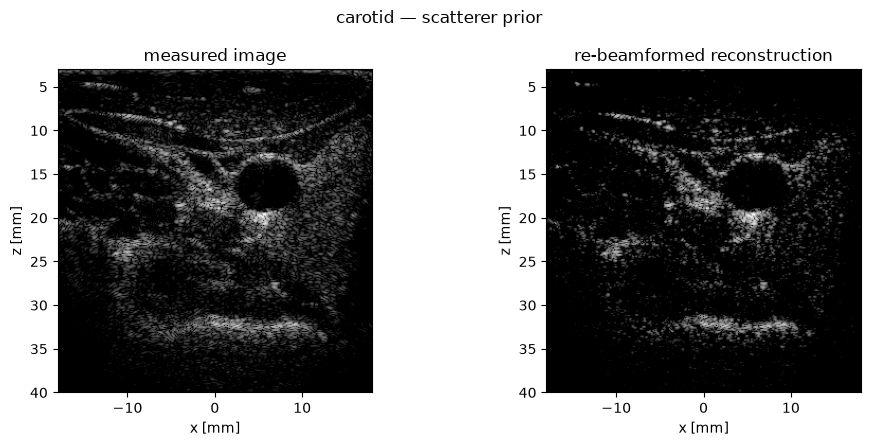

saved inverse_beamforming_carotid_prebf.gif (4.1 MB)


In [8]:
if run_inversion:
    show_images(operator, image, result_carotid, REGION_CAROTID, title="carotid — scatterer prior")
    render_prebf_gif(
        "inverse_beamforming_carotid_prebf.gif",
        raw_data,
        result_carotid.channel_data,
        transmits=range(0, parameters.n_tx, 4),  # subsample transmits to keep the GIF small
        fps=10,
    )

![carotid pre-beamformed channel data: recorded vs recovered](inverse_beamforming_carotid_prebf.gif)

## Takeaways

- The inversion reproduces the reference result of the
  [original study](https://github.com/sankethvedula/das-inverse).
- The re-beamformed image matches the measured image well (post-BF corr ≈0.95), yet the
  channel data itself stays unrecoverable (pre-BF corr ≈0.06): in-vivo **speckle** lives
  almost entirely in the nullspace of the compounded DAS operator.
- This ceiling is fundamental, not a tuning issue — the image simply does not carry the
  channel-data micro-realization. Bright point targets are a different story: see the
  [CIRS phantom tutorial](inverse_beamforming_cirs_example.ipynb).